# CNN 복습

CNN(Convolutional Neural Network, 합성곱 신경망)은 이미지처럼 격자 구조를 가진 데이터에서 가까운 위치의 패턴을 찾고, 이를 여러 층에서 조합해 분류에 필요한 표현을 학습하는 신경망이다. 완전연결층만 사용할 때보다 이미지의 공간 관계를 보존하고 같은 커널을 여러 위치에 공유하므로 파라미터를 효율적으로 사용할 수 있다.

이 복습에서는 앞선 딥러닝 단원의 긴 데이터 다운로드와 전체 모델 학습을 반복하지 않는다. 작은 합성 이미지를 CPU에서 빠르게 실행하면서 `(B, C, H, W)` 입력이 `Conv2d → ReLU → Pooling`을 통과하는 shape 변화, 짧은 학습 전후의 성능 변화, feature extractor와 classifier head의 경계를 확인한다. 마지막에는 CNN 표현이 ViT와 CLIP의 표현 방식과 어디에서 이어지고 어디에서 달라지는지 정리한다.

## 1. CNN이 이미지에 맞는 이유

**귀납 편향(inductive bias)** 은 모델이 데이터를 보기 전부터 어떤 패턴이 중요할 것이라고 가정하는 설계 원리이다. CNN은 이미지의 모든 픽셀을 처음부터 서로 연결하지 않고 다음 가정을 활용한다.

- **지역 연결(local connectivity)**: 가까운 픽셀들이 모서리와 질감 같은 지역 패턴을 만든다고 가정한다. 작은 커널이 한 번에 입력의 일부 영역만 확인한다.
- **가중치 공유(weight sharing)**: 같은 커널을 이미지 전체 위치에 반복 적용한다. 위치마다 별도 가중치를 두는 것보다 파라미터 수가 적다.
- **이동 등변성(translation equivariance)**: 입력의 패턴이 이동하면 feature map의 반응도 대체로 같은 방향으로 이동한다. 경계, stride와 padding 설정에 따라 완전한 등변성이 깨질 수 있다.

Pooling은 가까운 영역의 반응을 요약해 작은 위치 변화에 덜 민감하게 만들 수 있지만, 어떤 이동에도 출력이 완전히 같아지는 이동 불변성을 자동으로 보장하지는 않는다. 이 구분은 뒤에서 feature map의 공간 축을 줄일 때 다시 확인한다.

## 2. 커널 이동과 합성곱 출력 크기

**커널(kernel)** 은 입력의 작은 창과 원소별 곱을 수행하는 학습 가능한 가중치 배열이다. 커널과 겹친 입력 창의 값을 원소별로 곱한 뒤 모두 더하고 bias를 더하면 feature map의 한 위치 값이 된다. 같은 계산을 커널의 위치를 옮겨 가며 반복하므로 하나의 feature map이 만들어진다.

![2D 합성곱에서 커널이 이동하는 과정](https://upload.wikimedia.org/wikipedia/commons/1/19/2D_Convolution_Animation.gif)

그림은 커널이 입력 창 위를 이동하며 각 위치에서 원소별 곱과 합을 계산하고, 그 합이 출력 feature map의 한 칸이 되는 순서로 읽는다. 출처: [Wikimedia Commons, 2D Convolution Animation](https://commons.wikimedia.org/wiki/File:2D_Convolution_Animation.gif), Michael Plotke, CC BY-SA 3.0.

높이 한 축의 합성곱 출력 크기는 다음과 같이 계산하며 너비에도 같은 공식을 적용한다.

$$
H_{out}=\left\lfloor\frac{H_{in}+2P-D(K-1)-1}{S}+1\right\rfloor
$$

여기서 $H_{in}$은 입력 높이, $K$는 커널 크기, $S$는 stride, $P$는 padding, $D$는 dilation이다. `stride=1`, `padding=1`, `dilation=1`, `kernel_size=3`이면 높이와 너비가 유지된다. `stride`가 커지면 커널의 이동 간격이 넓어져 출력 공간 크기가 작아지고, `padding`은 가장자리 주변에 값을 추가해 경계 정보와 출력 크기를 조절한다.

### 실행 환경 설정

In [13]:
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(7)

torch.set_num_threads(1)
device = torch.device("cpu")

print("PyTorch version:", torch.__version__)
print("device:", device)

PyTorch version: 2.13.0
device: cpu


### Feature map 한 위치의 계산

앞의 애니메이션에서 본 한 위치의 계산을 3×3 숫자로 확인한다. 입력 창과 커널의 같은 위치끼리 곱한 배열을 만든 뒤 모든 값을 더하면 feature map의 값 하나가 된다. 아래 세로 경계 커널은 원리를 확인하기 위해 직접 정한 고정값이며 학습된 커널이 아니다. 실제 `Conv2d`는 이 가중치와 bias를 손실을 줄이는 방향으로 학습한다.

In [14]:
input_window = torch.tensor([ # 입력된 이미지
    [1.0, 1.0, 0.0],
    [1.0, 1.0, 0.0],
    [1.0, 1.0, 0.0],
])

vertical_edge_kernel = torch.tensor([ # 커널
    [1.0, 0.0, -1.0],
    [1.0, 0.0, -1.0],
    [1.0, 0.0, -1.0],
])

elementwise_products = input_window * vertical_edge_kernel # 입력된 이미지 * 커널 -> 같은 칸의 값들을 곱함
one_feature_value = elementwise_products.sum()

print("elementwise products:\n", elementwise_products)
print("sum → one feature-map value:", one_feature_value.item())

elementwise products:
 tensor([[1., 0., -0.],
        [1., 0., -0.],
        [1., 0., -0.]])
sum → one feature-map value: 3.0


### `(B, C, H, W)` 입력과 `Conv2d → ReLU → Pooling`

```
B : Batch
C : Channels (1 : 흑백 / 3 : RGB)
H : Height
W : Width
```

- **Conv2d** : input -> kernel
- **ReLU** : 음수값 제거
- **Pooling** : 이미지 크기 축소

PyTorch의 이미지 배치는 `(B, C, H, W)` 순서이다. `B`는 한 번에 처리하는 이미지 수, `C`는 채널 수, `H`와 `W`는 높이와 너비이다. 흑백 이미지는 보통 `C=1`, RGB 이미지는 `C=3`이다.

아래 `Conv2d`에서 `in_channels=1`은 입력의 흑백 채널 수, `out_channels=4`는 서로 다른 필터와 출력 feature map의 수이다. `kernel_size=3`은 3×3 창, `stride=1`은 한 칸 이동, `padding=1`은 입력 둘레에 한 칸을 추가한다. `ReLU`는 음수를 0으로 바꾸되 shape는 유지하고, `MaxPool2d(kernel_size=2, stride=2)`는 2×2 영역의 최댓값을 남겨 높이와 너비를 절반으로 줄인다.

이 셀의 커널은 아직 학습되지 않은 무작위 초기 가중치이다. 따라서 출력값의 의미를 학습된 모서리나 질감이라고 해석하지 않고 계층별 shape 계약만 확인한다.

In [15]:
# 입력 이미지 2장, 흑백 1채널, 크기 8 * 8
review_image = torch.linspace(-1, 1, steps = 2 * 1 * 8 * 8).reshape(2, 1, 8, 8)

shape_conv = nn.Conv2d(
    in_channels = 1,
    out_channels = 4,
    kernel_size = 3,
    stride = 1, # 커널이 한번에 움직이는 칸 수
    padding = 1
)

shape_relu = nn.ReLU() # 음수 제거


# 2 * 2 영역을 두 칸씩 이동
shape_pool = nn.MaxPool2d(kernel_size = 2, stride = 2)

# CNN 통과 -> feature map (kernel을 통과해서 나온 값)
# 이미지의 특징들이 반영된 숫자로 이루어져 있음
feature_maps = shape_conv(review_image)

# 활성화 함수 통과
activated_maps = shape_relu(feature_maps)

# 크기 감소 (과적합 감소, 일반화 능력 향상)
pooled_maps = shape_pool(activated_maps)

expected_size = math.floor((8 + 2 * 1 - 1 * (3 - 1) - 1) / 1 + 1)
print("input:", tuple(review_image.shape))
print("Conv2d weight:", tuple(shape_conv.weight.shape))
print("formula H_out=W_out:", expected_size)
print("Conv2d:", tuple(feature_maps.shape))
print("ReLU:", tuple(activated_maps.shape))
print("MaxPool2d:", tuple(pooled_maps.shape))
print("negative values after ReLU:", int((activated_maps < 0).sum()))

input: (2, 1, 8, 8)
Conv2d weight: (4, 1, 3, 3)
formula H_out=W_out: 8
Conv2d: (2, 4, 8, 8)
ReLU: (2, 4, 8, 8)
MaxPool2d: (2, 4, 4, 4)
negative values after ReLU: 0


## 3. 데이터 다운로드 없는 작은 합성 이미지 분류

CNN의 전체 학습 흐름을 짧게 재현하기 위해 16×16 흑백 이미지를 직접 만든다. 클래스 0은 세로 막대, 클래스 1은 가로 막대이며 막대 위치를 조금씩 이동시키고 픽셀 잡음을 더한다. 모델은 막대의 정확한 위치를 외우는 대신 방향 패턴을 구분해야 한다.

학습 데이터 240장은 가중치를 갱신하는 데 사용하고, 검증 데이터 80장은 가중치 갱신에는 사용하지 않은 이미지에서 epoch별 성능 변화를 관찰하는 데 사용한다. 따라서 이 80장은 test set이 아니라 validation set이다. 이 짧은 복습에서는 별도 test set을 만들지 않으며, 실제 프로젝트에서는 학습 설정을 고르는 validation set과 최종 성능을 한 번 확인하는 test set을 분리해야 한다. 이 합성 데이터는 CNN 학습 순서를 빠르게 확인하기 위한 예시이며 FashionMNIST나 CIFAR-10 같은 실제 데이터셋의 일반화 성능을 대신하지 않는다.

In [16]:
def make_stripe_data(sample_count, generator):
    # 반환 shape는 이미지 `(sample_count,1,16,16)`, 정답 `(sample_count,)`이다.
    images = torch.zeros(sample_count, 1, 16, 16)
    labels = torch.arange(sample_count) % 2

    # 위치를 조금 바꿔도 같은 방향 클래스로 분류하도록 막대 중심을 -2~2칸 이동한다.
    for index, label in enumerate(labels):
        center = 8 + int(torch.randint(-2, 3, (1,), generator=generator))
        if label.item() == 0:
            images[index, 0, :, center - 1:center + 2] = 1.0
        else:
            images[index, 0, center - 1:center + 2, :] = 1.0

    # 픽셀 잡음을 더한 뒤 유효한 밝기 범위 [0,1]로 제한한다.
    noise = 0.15 * torch.randn(images.shape, generator=generator)
    images = (images + noise).clamp(0.0, 1.0)
    order = torch.randperm(sample_count, generator=generator)
    return images[order], labels[order]

data_generator = torch.Generator().manual_seed(7)

# 학습용 이미지, 정답 240개 생성
train_images, train_labels = make_stripe_data(240, data_generator)

# 검증용 이미지, 정답 80개 생성
validation_images, validation_labels = make_stripe_data(80, data_generator)

print("train images:", tuple(train_images.shape), train_images.dtype)
print("train labels:", tuple(train_labels.shape), train_labels.dtype)
print("validation images:", tuple(validation_images.shape))
print("pixel range:", float(train_images.min()), float(train_images.max()))
print("class counts:", torch.bincount(train_labels).tolist())

print(train_images[0])

train images: (240, 1, 16, 16) torch.float32
train labels: (240,) torch.int64
validation images: (80, 1, 16, 16)
pixel range: 0.0 1.0
class counts: [120, 120]
tensor([[[0.0000, 0.0000, 0.0608, 0.0000, 0.0000, 0.2111, 0.0000, 0.0594,
          0.3229, 0.9533, 0.7848, 1.0000, 0.0000, 0.0817, 0.0787, 0.0000],
         [0.2168, 0.0000, 0.0000, 0.1577, 0.0000, 0.1868, 0.0470, 0.0436,
          0.0000, 0.9722, 1.0000, 1.0000, 0.0787, 0.1970, 0.2031, 0.0990],
         [0.3117, 0.0000, 0.0000, 0.0768, 0.0000, 0.1781, 0.0000, 0.0000,
          0.0000, 1.0000, 1.0000, 0.9120, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.1143, 0.1571, 0.0000, 0.0000, 0.0747, 0.0000, 0.0520,
          0.0090, 1.0000, 1.0000, 1.0000, 0.1196, 0.0000, 0.0133, 0.0000],
         [0.0000, 0.1387, 0.0420, 0.0000, 0.1158, 0.1095, 0.0000, 0.0946,
          0.0000, 0.9367, 1.0000, 0.6850, 0.0146, 0.2304, 0.0000, 0.1581],
         [0.0000, 0.0000, 0.0000, 0.0936, 0.0000, 0.0066, 0.0000, 0.0260,
          0.0000, 1.00

### 합성 이미지와 정답 확인

학습 전에 입력과 정답의 관계를 눈으로 확인한다. 각 패널의 제목은 클래스 index와 방향 이름을 함께 표시한다. 세로·가로 막대의 위치가 샘플마다 조금 다르고 배경에 잡음이 있지만 사람이 방향을 구분할 수 있어야 한다. 이 확인은 잘못된 label이나 shape를 가진 데이터로 학습을 시작하는 실수를 줄인다.

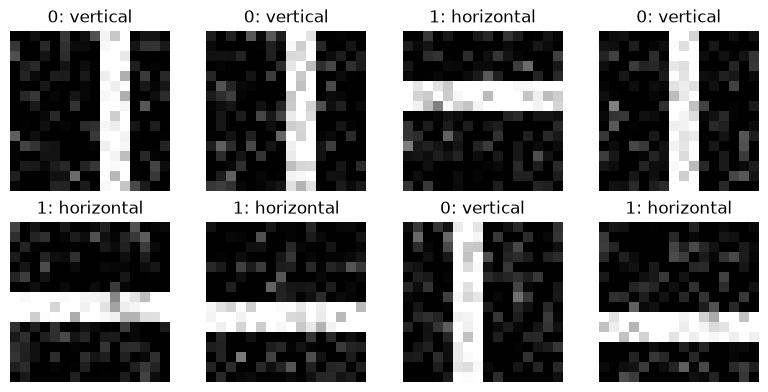

In [17]:
class_names = {0: "vertical", 1: "horizontal"}
figure, axes = plt.subplots(2, 4, figsize=(8, 4))

# squeeze(0)은 흑백 채널 축만 제거해 imshow가 받는 2차원 배열로 바꾼다.
for sample_index, axis in enumerate(axes.flat):
    image = train_images[sample_index].squeeze(0)
    label = int(train_labels[sample_index])
    axis.imshow(image, cmap="gray")
    axis.set_title(f"{label}: {class_names[label]}")
    axis.axis("off")

figure.tight_layout()
plt.show()

## 4. Feature extractor, embedding과 classifier head

CNN 분류 모델은 역할에 따라 두 부분으로 나눌 수 있다. **Feature extractor**는 `Conv2d`, ReLU와 pooling을 사용해 입력 이미지를 공간 feature map `(B, C, H, W)`로 변환한다. **Classifier head**는 추출된 표현을 클래스별 logits `(B, K)`로 바꾼다. `K`는 클래스 수이며 이 실습에서는 2이다.

![전형적인 CNN의 feature extractor와 classifier 구조](https://upload.wikimedia.org/wikipedia/commons/6/63/Typical_cnn.png)

그림은 왼쪽 입력에서 시작해 convolution과 subsampling이 공간 특징을 추출하고, 오른쪽 fully connected 계층이 분류 출력을 만드는 순서로 읽는다. 출처: [Wikimedia Commons, Typical cnn](https://commons.wikimedia.org/wiki/File:Typical_cnn.png), Aphex34, CC BY-SA 4.0.

**Global average pooling(GAP)** 은 각 feature map의 높이와 너비 전체를 평균 내 `(B, C, 1, 1)`로 만든다. 이어서 `Flatten`이 `(B, C)` 벡터로 바꾸며 이 벡터를 **embedding**이라고 부른다. embedding은 이미지의 압축 표현이고, classifier head는 이 표현을 현재 과제의 logits로 변환한다.

아래 모델은 16개 채널의 feature map을 GAP로 요약해 16차원 embedding을 만든다. 처음에는 가중치가 무작위이므로 이 셀에서는 표현의 의미가 아니라 shape와 모듈 경계만 확인한다.

In [18]:
torch.manual_seed(11)

INPUT_CHANNELS = 1
FIRST_FEATURE_CHANNELS = 8
SECOND_FEATURE_CHANNELS = 16
KERNEL_SIZE = 3
PADDING = 1
POOL_SIZE = 2
POOL_STRIDE = 2
NUM_CLASSES = 2

# nn.Sequential(신경망 | 활성화 함수 | pooling ...) : 순차적으로 수행
feature_extractor = nn.Sequential(
    nn.Conv2d(INPUT_CHANNELS, FIRST_FEATURE_CHANNELS, kernel_size = KERNEL_SIZE , padding = PADDING), # 16 * 16
    nn.ReLU(), # 활성화
    nn.MaxPool2d(kernel_size = POOL_SIZE, stride = POOL_STRIDE), # 8 * 8
    nn.Conv2d(FIRST_FEATURE_CHANNELS, SECOND_FEATURE_CHANNELS, kernel_size=KERNEL_SIZE, padding=PADDING), # 8 * 8
    nn.ReLU() # 활성화
)


# GAP : 공간 축을 1 * 1로 요약하고 flatten을 이용해 배치 축을 보존한 16차원 embedding 데이터 생성
global_pool =nn.AdaptiveAvgPool2d((1, 1)) # 튜플 전달
embedding_layer = nn.Flatten(start_dim = 1) # 1 * 1 -> 1

classifier_head = nn.Linear(16, 2)

# 입력된 이미지가 수직인지 수평인지 구분하는 모델
model = nn.Sequential(
    feature_extractor,
    global_pool,
    embedding_layer,
    classifier_head
)

sample_batch = train_images[:4].to(device)
sample_feature_maps = feature_extractor(sample_batch)
sample_pooled = global_pool(sample_feature_maps)
sample_embeddings = embedding_layer(sample_pooled)
sample_logits = classifier_head(sample_embeddings)

print("input:", tuple(sample_batch.shape))
print("feature maps:", tuple(sample_feature_maps.shape))
print("global pooled:", tuple(sample_pooled.shape))
print("embedding:", tuple(sample_embeddings.shape))
print("logits:", tuple(sample_logits.shape))

input: (4, 1, 16, 16)
feature maps: (4, 16, 8, 8)
global pooled: (4, 16, 1, 1)
embedding: (4, 16)
logits: (4, 2)


앞에서 정리한 역할과 준비된 구조 상수에 맞춰 feature extractor, global average pooling, embedding 계층과 classifier head를 연결한다. 다음 셀에서는 각 모듈을 정의하고 하나의 분류 모델로 구성한다.

준비된 sample_batch를 모델의 각 경계에 통과시켜 feature map, pooled tensor, embedding과 logits의 shape를 순서대로 확인한다. 앞 셀에서 모델을 구성한 뒤 다음 셀을 실행한다.

### 손실함수, optimizer와 학습 전 기준 성능

`CrossEntropyLoss`는 모델의 원시 점수인 `(B, 2)` logits와 `(B,)` 정수 label을 비교해 하나의 손실값을 계산한다. 이 함수 안에 log-softmax 계산이 포함되므로 모델 출력에 softmax를 먼저 적용하지 않는다.

`Adam` optimizer는 `loss.backward()`가 계산한 기울기를 이용해 모델의 커널과 classifier 가중치를 갱신한다. 학습 전 정확도는 무작위 초기 모델의 기준선이며, 두 클래스가 균형인 이 데이터에서는 우연 수준인 약 50%와 비교한다. 평가할 때는 `model.eval()`과 `torch.no_grad()`를 사용해 가중치를 바꾸지 않는다.

In [19]:
def accuracy(model, images, labels):
    model.eval()
    with torch.no_grad():
        logits = model(images) # models 반환 logits [[0.7], [0.5]]
        predictions = logits.argmax(dim=1) # 가장 큰 수의 인덱스 값을 찾기

    # 정답과 같은 예측 비율을 반환
    return (predictions == labels).float().mean().item()

# 손실 함수
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.03)

# 검증 정확도
initial_validation_accuracy = accuracy(model, validation_images, validation_labels)

print(f'initial_validation_accuracy : {initial_validation_accuracy:.3f}')

initial_validation_accuracy : 0.500


### 가중치 갱신
매 epoch 뒤 학습과 검증 정확도를 모두 기록한다. 학습 정확도와 검증 정확도가 함께 증가하면 방향 패턴이 가중치 갱신에 사용하지 않은 합성 이미지에도 적용된 것이다. 학습 정확도만 높고 검증 정확도가 정체되면 데이터 분할, 과적합 또는 학습 규칙의 불일치를 점검해야 한다. 반복해서 확인하는 검증 정확도는 최종 test 성능이 아니며, 이 결과를 실제 이미지 분류 성능으로 일반화하지 않는다.

In [20]:
history = {"loss": [], "train_acc": [], "validation_acc": []}
epochs = 12

for epoch in range(epochs):
    # train 모드에서 이전 기울기를 지운 뒤 현재 가중치로 logits와 loss를 계산한다.
    model.train()
    optimizer.zero_grad(set_to_none=True)
    train_logits = model(train_images)
    loss = criterion(train_logits, train_labels)

    # backward가 기울기를 계산하고 step이 모델 파라미터를 실제로 갱신한다.
    loss.backward()
    optimizer.step()

    train_acc = accuracy(model, train_images, train_labels)
    validation_acc = accuracy(model, validation_images, validation_labels)
    history["loss"].append(loss.item())
    history["train_acc"].append(train_acc)
    history["validation_acc"].append(validation_acc)

    if epoch == 0 or (epoch + 1) % 3 == 0:
        print(
            f"epoch {epoch + 1:02d} | loss={loss.item():.4f} | "
            f"train_acc={train_acc:.3f} | validation_acc={validation_acc:.3f}"
        )

final_validation_accuracy = history["validation_acc"][-1]
print(f"accuracy change: {initial_validation_accuracy:.3f} → {final_validation_accuracy:.3f}")

epoch 01 | loss=0.6946 | train_acc=0.500 | validation_acc=0.500
epoch 03 | loss=0.6830 | train_acc=0.500 | validation_acc=0.500
epoch 06 | loss=0.6483 | train_acc=0.992 | validation_acc=0.988
epoch 09 | loss=0.4981 | train_acc=1.000 | validation_acc=1.000
epoch 12 | loss=0.2226 | train_acc=1.000 | validation_acc=1.000
accuracy change: 0.500 → 1.000


위에서 준비한 epoch 수와 기록용 history를 사용해 학습 루프를 구성한다. 다음 셀에서는 각 epoch마다 기울기를 초기화하고, 순전파·손실 계산·역전파·가중치 갱신을 수행한 뒤 학습 및 검증 지표를 기록한다.

### 학습 곡선과 예측 결과 해석

왼쪽 그래프는 epoch가 진행될 때 `CrossEntropyLoss`가 어떻게 변하는지 보여 준다. 오른쪽 그래프는 학습 데이터와 검증 데이터의 정확도를 같은 축에서 비교한다. 손실이 낮아지고 두 정확도가 함께 높아지는지가 정상 학습의 기준이다.

마지막에는 검증 이미지 8개의 예측과 정답을 함께 출력한다. 정확도 하나만 볼 때보다 개별 예측을 확인하면 label mapping이 뒤집히거나 한 클래스만 계속 예측하는 문제를 더 빨리 찾을 수 있다.

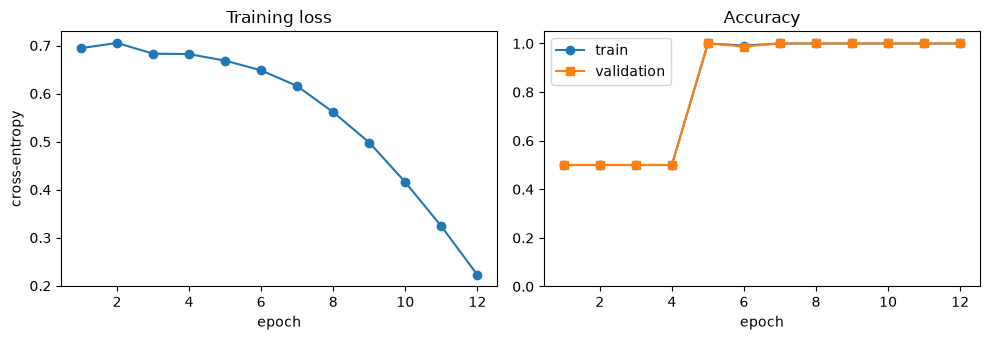

targets:     [1, 1, 1, 0, 0, 1, 0, 1]
predictions: [1, 1, 1, 0, 0, 1, 0, 1]


In [21]:
epoch_axis = range(1, epochs + 1)
figure, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].plot(epoch_axis, history["loss"], marker="o")
axes[0].set_title("Training loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("cross-entropy")

axes[1].plot(epoch_axis, history["train_acc"], marker="o", label="train")
axes[1].plot(epoch_axis, history["validation_acc"], marker="s", label="validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("epoch")
axes[1].set_ylim(0.0, 1.05)
axes[1].legend()
figure.tight_layout()
plt.show()

model.eval()
with torch.no_grad():
    sample_predictions = model(validation_images[:8]).argmax(dim=1)

print("targets:    ", validation_labels[:8].tolist())
print("predictions:", sample_predictions.tolist())

## 5.다음 ViT·CLIP 연결 준비

feature extractor의 출력은 `(B, 16, 8, 8)` feature map이다.

GAP는 각 채널의 공간 평균을 계산하고 `Flatten`은 `(B, 16)` embedding을 만든다.

classifier head는 이 embedding을 `(B, 2)` logits로 변환한다.


---

ViT는 이미지를 patch token sequence `(B, T, D)`로 표현한다. CNN의 공간 feature map `(B, C, H, W)`과 ViT의 token sequence는 구조가 다르다. CLIP은 이 원시 구조를 그대로 비교하지 않고 각 encoder가 만든 전역 표현을 projection한 `(B, D)` 이미지·텍스트 embedding을 같은 공간에서 비교한다.

In [22]:
history = {"loss": [], "train_acc": [], "validation_acc": []}
epochs = 12

for epoch in range(epochs):
    # train 모드에서 이전 기울기를 지운 뒤 현재 가중치로 logits와 loss를 계산한다.
    model.train()
    optimizer.zero_grad(set_to_none=True)
    train_logits = model(train_images)
    loss = criterion(train_logits, train_labels)

    # backward가 기울기를 계산하고 step이 모델 파라미터를 실제로 갱신한다.
    loss.backward()
    optimizer.step()

    train_acc = accuracy(model, train_images, train_labels)
    validation_acc = accuracy(model, validation_images, validation_labels)
    history["loss"].append(loss.item())
    history["train_acc"].append(train_acc)
    history["validation_acc"].append(validation_acc)

    if epoch == 0 or (epoch + 1) % 3 == 0:
        print(
            f"epoch {epoch + 1:02d} | loss={loss.item():.4f} | "
            f"train_acc={train_acc:.3f} | validation_acc={validation_acc:.3f}"
        )

final_validation_accuracy = history["validation_acc"][-1]
print(f"accuracy change: {initial_validation_accuracy:.3f} → {final_validation_accuracy:.3f}")

epoch 01 | loss=0.1369 | train_acc=1.000 | validation_acc=1.000
epoch 03 | loss=0.0330 | train_acc=1.000 | validation_acc=1.000
epoch 06 | loss=0.0018 | train_acc=1.000 | validation_acc=1.000
epoch 09 | loss=0.0001 | train_acc=1.000 | validation_acc=1.000
epoch 12 | loss=0.0000 | train_acc=1.000 | validation_acc=1.000
accuracy change: 0.500 → 1.000
